Problem Statement:<br>
Predict whether a patient has heart disease or not based on different variable through classification.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('heart_disease_uci.csv')
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [3]:
df.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
df.tail(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


In [5]:
df.shape

(920, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [7]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [8]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [9]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [10]:
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
df['chol'] = df['chol'].fillna(df['chol'].median())
df['fbs'] = df['fbs'].fillna(df['fbs'].mode()[0])
df['restecg'] = df['restecg'].fillna(df['restecg'].mode()[0])
df['thalch'] = df['thalch'].fillna(df['thalch'].median())
df['exang'] = df['exang'].fillna(df['exang'].mode()[0])
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())
df['slope'] = df['slope'].fillna(df['slope'].mode()[0])
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

C:\Users\acer\AppData\Local\Temp\ipykernel_8572\2502527113.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fbs'] = df['fbs'].fillna(df['fbs'].mode()[0])
C:\Users\acer\AppData\Local\Temp\ipykernel_8572\2502527113.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang'] = df['exang'].fillna(df['exang'].mode()[0])


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
categorical_cols = ['sex','cp','fbs','restecg','exang','slope','thal']

df[categorical_cols] = df[categorical_cols].astype('category')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   id        920 non-null    int64   
 1   age       920 non-null    int64   
 2   sex       920 non-null    category
 3   dataset   920 non-null    object  
 4   cp        920 non-null    category
 5   trestbps  920 non-null    float64 
 6   chol      920 non-null    float64 
 7   fbs       920 non-null    category
 8   restecg   920 non-null    category
 9   thalch    920 non-null    float64 
 10  exang     920 non-null    category
 11  oldpeak   920 non-null    float64 
 12  slope     920 non-null    category
 13  ca        920 non-null    float64 
 14  thal      920 non-null    category
 15  num       920 non-null    int64   
dtypes: category(7), float64(5), int64(3), object(1)
memory usage: 72.0+ KB


In [14]:
df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

In [15]:
df['target'].value_counts()

target
1    509
0    411
Name: count, dtype: int64

0 → No heart disease

1 → Heart disease

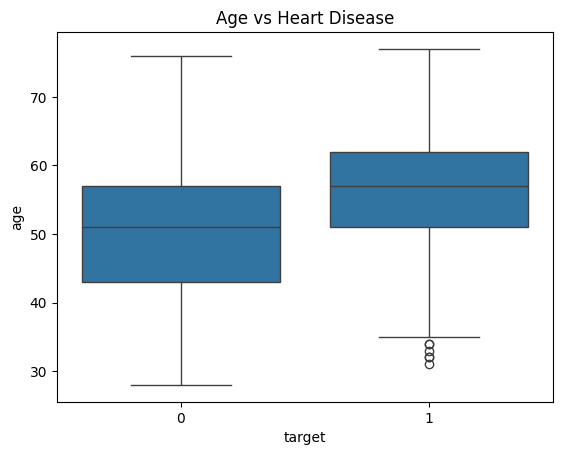

In [16]:
sns.boxplot(x='target', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

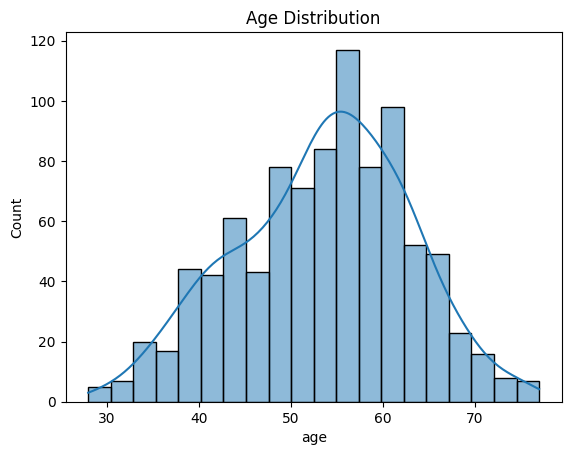

In [17]:
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

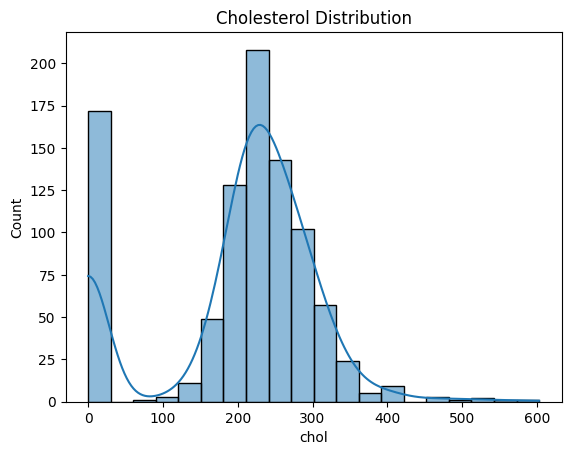

In [18]:
sns.histplot(df['chol'], bins=20, kde=True)
plt.title("Cholesterol Distribution")
plt.show()

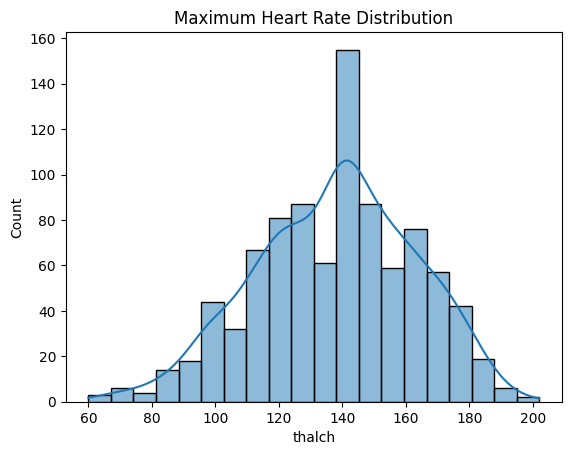

In [19]:
sns.histplot(df['thalch'], bins=20, kde=True)
plt.title("Maximum Heart Rate Distribution")
plt.show()

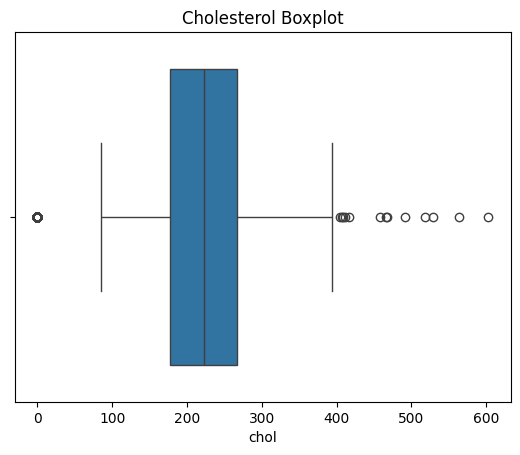

In [20]:
sns.boxplot(x=df['chol'])
plt.title("Cholesterol Boxplot")
plt.show()

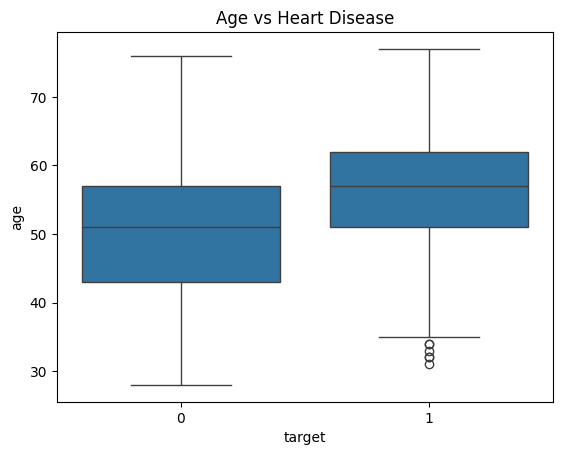

In [21]:
sns.boxplot(x='target', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

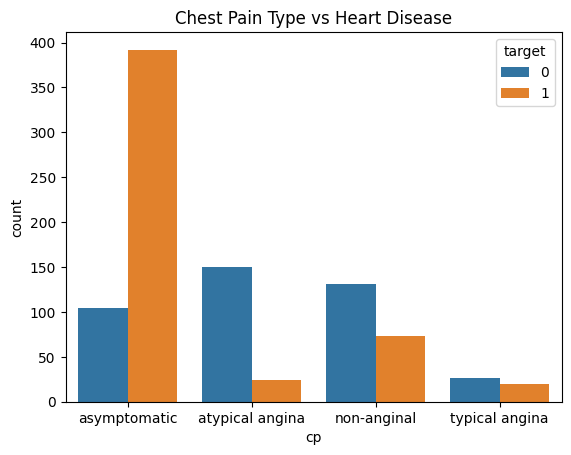

In [22]:
sns.countplot(x='cp', hue='target', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

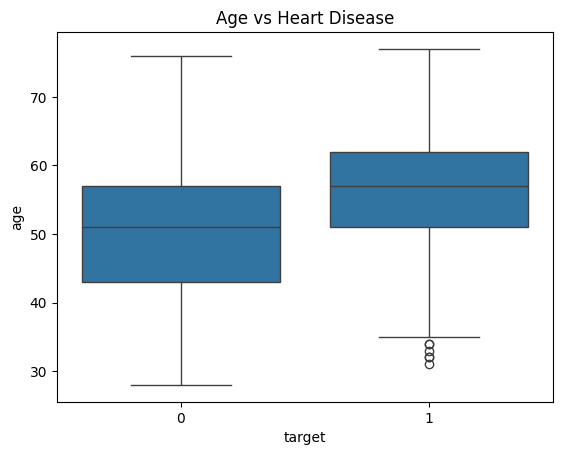

In [23]:
sns.boxplot(x='target', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

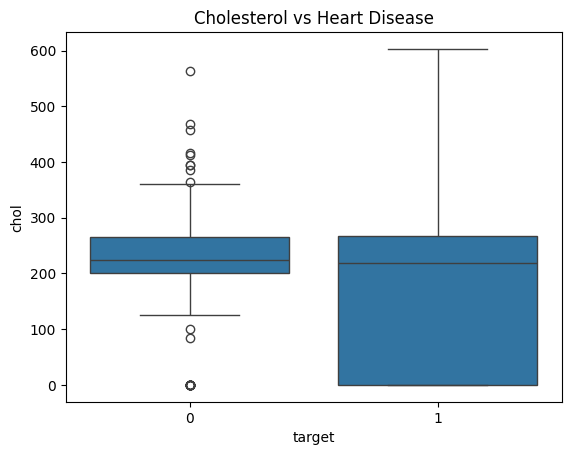

In [24]:
sns.boxplot(x='target', y='chol', data=df)
plt.title("Cholesterol vs Heart Disease")
plt.show()

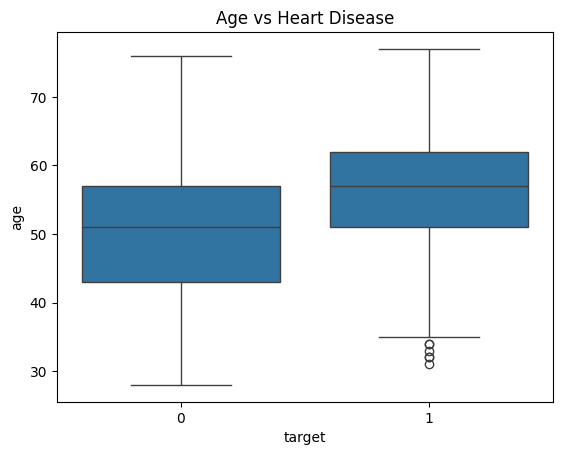

In [25]:
sns.boxplot(x='target', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

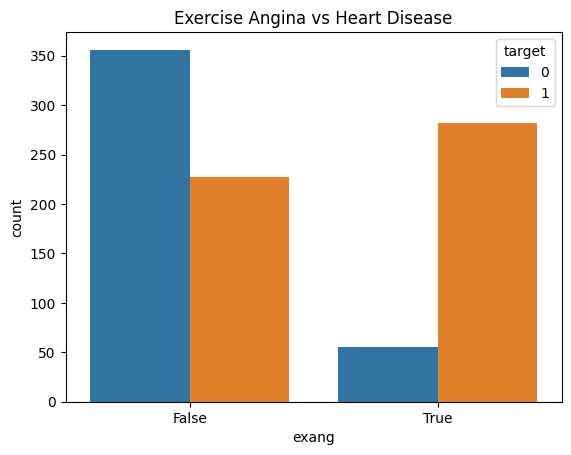

In [26]:
sns.countplot(x='exang', hue='target', data=df)
plt.title("Exercise Angina vs Heart Disease")
plt.show()

In [27]:
corr_matrix = df.select_dtypes(include=['number']).corr()
print(corr_matrix)

                id       age  trestbps      chol    thalch   oldpeak  \
id        1.000000  0.239301  0.039382 -0.370721 -0.428727  0.014034   
age       0.239301  1.000000  0.230784 -0.086010 -0.349715  0.233550   
trestbps  0.039382  0.230784  1.000000  0.089484 -0.104747  0.161217   
chol     -0.370721 -0.086010  0.089484  1.000000  0.226047  0.047454   
thalch   -0.428727 -0.349715 -0.104747  0.226047  1.000000 -0.149401   
oldpeak   0.014034  0.233550  0.161217  0.047454 -0.149401  1.000000   
ca       -0.385881  0.219413  0.039092  0.152514  0.038207  0.218412   
num       0.273552  0.339596  0.113178 -0.230539 -0.349173  0.411588   
target    0.356086  0.282700  0.101273 -0.228976 -0.381864  0.366138   

                ca       num    target  
id       -0.385881  0.273552  0.356086  
age       0.219413  0.339596  0.282700  
trestbps  0.039092  0.113178  0.101273  
chol      0.152514 -0.230539 -0.228976  
thalch    0.038207 -0.349173 -0.381864  
oldpeak   0.218412  0.411588  0.3

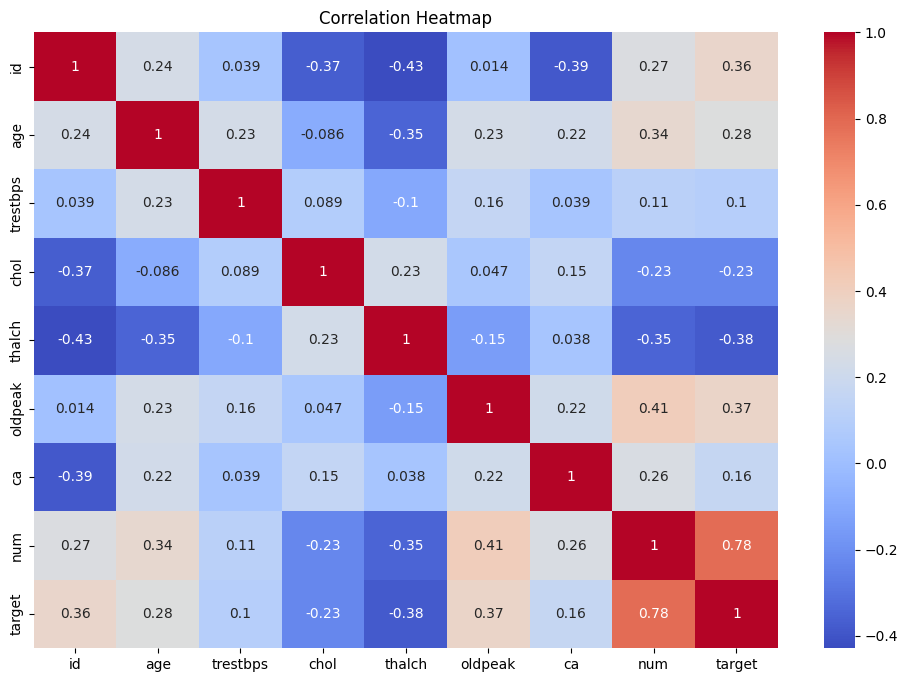

In [28]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [29]:
# converting categories into numerical form using one hot encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [30]:
df.columns

Index(['id', 'age', 'dataset', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca',
       'num', 'target', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal',
       'cp_typical angina', 'fbs_True', 'restecg_normal',
       'restecg_st-t abnormality', 'exang_True', 'slope_flat',
       'slope_upsloping', 'thal_normal', 'thal_reversable defect'],
      dtype='object')

In [31]:
X = df.drop(['target','id','dataset','num'], axis=1)
y = df['target']

In [32]:
print(X.columns)

Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_Male',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True',
       'restecg_normal', 'restecg_st-t abnormality', 'exang_True',
       'slope_flat', 'slope_upsloping', 'thal_normal',
       'thal_reversable defect'],
      dtype='object')


In [33]:
X.head()

,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,150.0,2.3,0.0,True,False,False,True,True,False,False,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,3.0,True,False,False,False,False,False,False,True,True,False,True,False
2,67,120.0,229.0,129.0,2.6,2.0,True,False,False,False,False,False,False,True,True,False,False,True
3,37,130.0,250.0,187.0,3.5,0.0,True,False,True,False,False,True,False,False,False,False,True,False
4,41,130.0,204.0,172.0,1.4,0.0,False,True,False,False,False,False,False,False,False,True,True,False


In [34]:
y.head()

0    0
1    1
2    1
3    0
4    0
Name: target, dtype: int64

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [38]:
# logistic regression
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train,y_train)
y_pred_log = log_model.predict(X_test)

In [39]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("Precision Score:")
print(precision_score(y_test, y_pred_log))

print("Recall Score:")
print(recall_score(y_test, y_pred_log))

print("F1 Score:")
print(f1_score(y_test, y_pred_log))

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_log))

Confusion Matrix:
[[60 15]
 [22 87]]
Precision Score:
0.8529411764705882
Recall Score:
0.7981651376146789
F1 Score:
0.8246445497630331
Accuracy Score:
0.7989130434782609


In [40]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train,y_train)
y_pred_knn=knn_model.predict(X_test)


In [41]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("Precision Score:")
print(precision_score(y_test, y_pred_knn))

print("Recall Score:")
print(recall_score(y_test, y_pred_knn))

print("F1 Score:")
print(f1_score(y_test, y_pred_knn))

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_knn))

Confusion Matrix:
[[62 13]
 [22 87]]
Precision Score:
0.87
Recall Score:
0.7981651376146789
F1 Score:
0.8325358851674641
Accuracy Score:
0.8097826086956522


In [59]:
from sklearn.svm import SVC

svc_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svc_model.fit(X_train, y_train)

y_pred_svc = svc_model.predict(X_test)

In [60]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svc))

print("Precision Score:")
print(precision_score(y_test, y_pred_svc))

print("Recall Score:")
print(recall_score(y_test, y_pred_svc))

print("F1 Score:")
print(f1_score(y_test, y_pred_svc))

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_svc))

Confusion Matrix:
[[65 10]
 [19 90]]
Precision Score:
0.9
Recall Score:
0.8256880733944955
F1 Score:
0.861244019138756
Accuracy Score:
0.842391304347826


In [61]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train,y_train)
y_pred_nb = nb_model.predict(X_test)

In [62]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("Precision Score:")
print(precision_score(y_test, y_pred_nb))

print("Recall Score:")
print(recall_score(y_test, y_pred_nb))

print("F1 Score:")
print(f1_score(y_test, y_pred_nb))

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_nb))

Confusion Matrix:
[[61 14]
 [22 87]]
Precision Score:
0.8613861386138614
Recall Score:
0.7981651376146789
F1 Score:
0.8285714285714286
Accuracy Score:
0.8043478260869565


In [63]:
from sklearn.metrics import classification_report

print('For logistic regression',classification_report(y_test, y_pred_log))
print('For KNN',classification_report(y_test, y_pred_knn))
print('For SVC',classification_report(y_test, y_pred_svc))
print('For Naive bayes',classification_report(y_test, y_pred_nb))

For logistic regression               precision    recall  f1-score   support

           0       0.73      0.80      0.76        75
           1       0.85      0.80      0.82       109

    accuracy                           0.80       184
   macro avg       0.79      0.80      0.79       184
weighted avg       0.80      0.80      0.80       184

For KNN               precision    recall  f1-score   support

           0       0.74      0.83      0.78        75
           1       0.87      0.80      0.83       109

    accuracy                           0.81       184
   macro avg       0.80      0.81      0.81       184
weighted avg       0.82      0.81      0.81       184

For SVC               precision    recall  f1-score   support

           0       0.77      0.87      0.82        75
           1       0.90      0.83      0.86       109

    accuracy                           0.84       184
   macro avg       0.84      0.85      0.84       184
weighted avg       0.85      0.84 

Final interpretation:
The Support Vector Classifier (SVC) performed best with the highest accuracy (84%) and F1-score, indicating a strong balance between precision and recall. Therefore, SVC is the most suitable model for predicting heart disease in this dataset.

## Save the Best Model

In [67]:
import pickle

with open("model.pkl","wb") as file:
    pickle.dump(svc_model,file)

print("Model Saved Successfully!")

Model Saved Successfully!


In [78]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully!")

Scaler saved successfully!


## SHAP Explainability

100%|██████████| 20/20 [01:04<00:00,  3.25s/it]


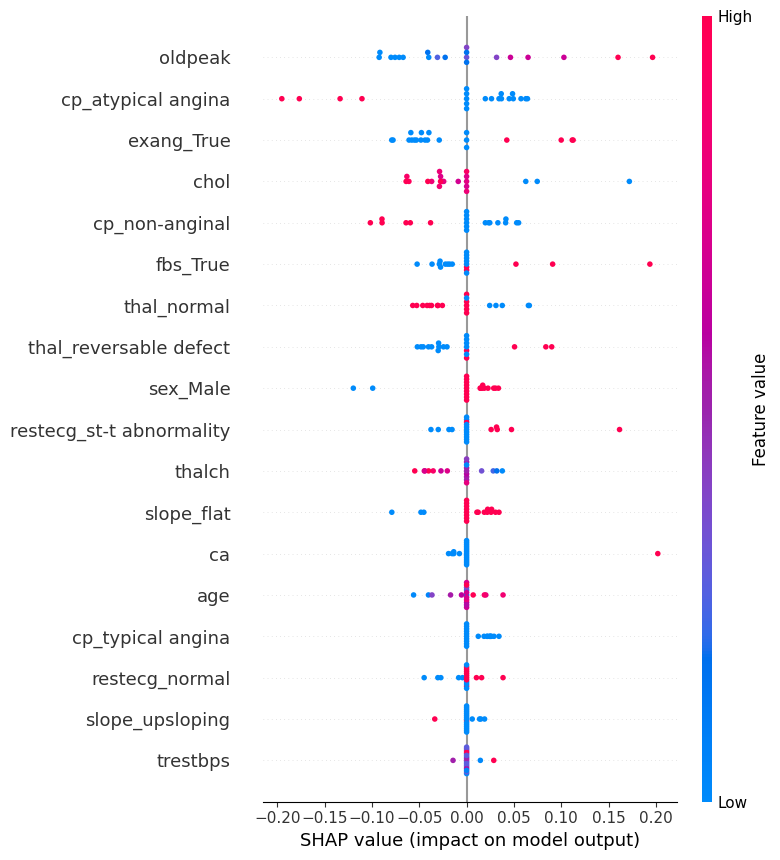

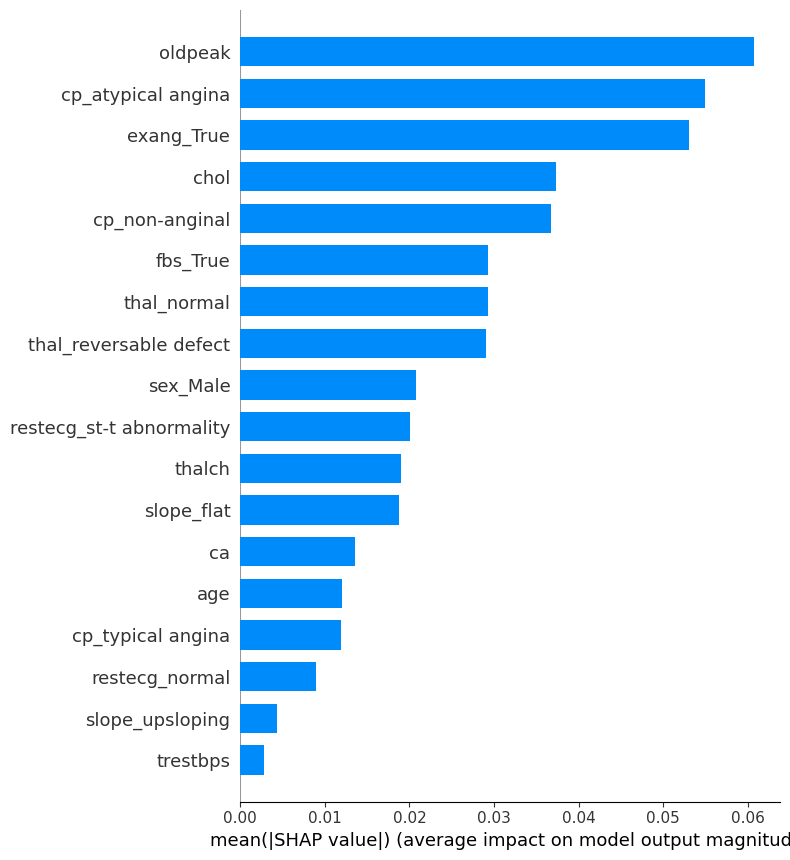

In [77]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Convert samples to DataFrames with correct column names
background = pd.DataFrame(
    shap.sample(X_train, 50, random_state=42),
    columns=X.columns
)

test_sample = pd.DataFrame(
    shap.sample(X_test, 20, random_state=42),
    columns=X.columns
)

# Create SHAP explainer
explainer = shap.KernelExplainer(
    svc_model.predict_proba,
    background
)

# Compute SHAP values
shap_values = explainer.shap_values(test_sample)

# For binary classification, use class 1 explanations
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values[:, :, 1]

# Summary Plot

shap.summary_plot(
    shap_values_class1,
    test_sample,
    feature_names=X.columns.tolist()
)

# Bar Plot

shap.summary_plot(
    shap_values_class1,
    test_sample,
    feature_names=X.columns.tolist(),
    plot_type="bar"
)
